In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load dataset
df = pd.read_csv("/content/Titanic Dataset.csv")

In [ ]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df))*100

print(missing_count.sort_values(ascending=False).head(10))
print(missing_percent.sort_values(ascending=False).head(10))

body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
sibsp           0
name            0
survived        0
dtype: int64
body         90.756303
cabin        77.463713
boat         62.872422
home.dest    43.086325
age          20.091673
embarked      0.152788
fare          0.076394
sibsp         0.000000
name          0.000000
survived      0.000000
dtype: float64


In [ ]:
# Simple imputation
df_mean = df.fillna(df.mean(numeric_only=True))
df_median = df.fillna(df.median(numeric_only=True))
df_mode = df.fillna(df.mode().iloc[0])

In [ ]:
# Forward fill
df_ffill = df.fillna(method='ffill')

/tmp/ipykernel_3293/2861128085.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')


In [ ]:
# KNN Imputation
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(imputer.fit_transform(df.select_dtypes(include=np.number)))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression


import missingno as msno

In [ ]:
df = pd.read_csv("/content/Titanic Dataset.csv")   # change path accordingly

print("Shape:", df.shape)
print(df.head())

Shape: (1309, 14)
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                  

In [ ]:
missing_count = df.isnull().sum()
print("\nMissing Count:\n", missing_count.sort_values(ascending=False))


Missing Count:
 body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
sibsp           0
name            0
survived        0
pclass          0
sex             0
parch           0
ticket          0
dtype: int64


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage:\n", missing_percent.sort_values(ascending=False))


Missing Percentage:
 body         90.756303
cabin        77.463713
boat         62.872422
home.dest    43.086325
age          20.091673
embarked      0.152788
fare          0.076394
sibsp         0.000000
name          0.000000
survived      0.000000
pclass        0.000000
sex           0.000000
parch         0.000000
ticket        0.000000
dtype: float64


In [ ]:
missing_cols = df.columns[df.isnull().any()]
print("\nColumns with Missing Values:\n", missing_cols)


Columns with Missing Values:
 Index(['age', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'], dtype='object')


In [ ]:
df['missing_per_row'] = df.isnull().sum(axis=1)

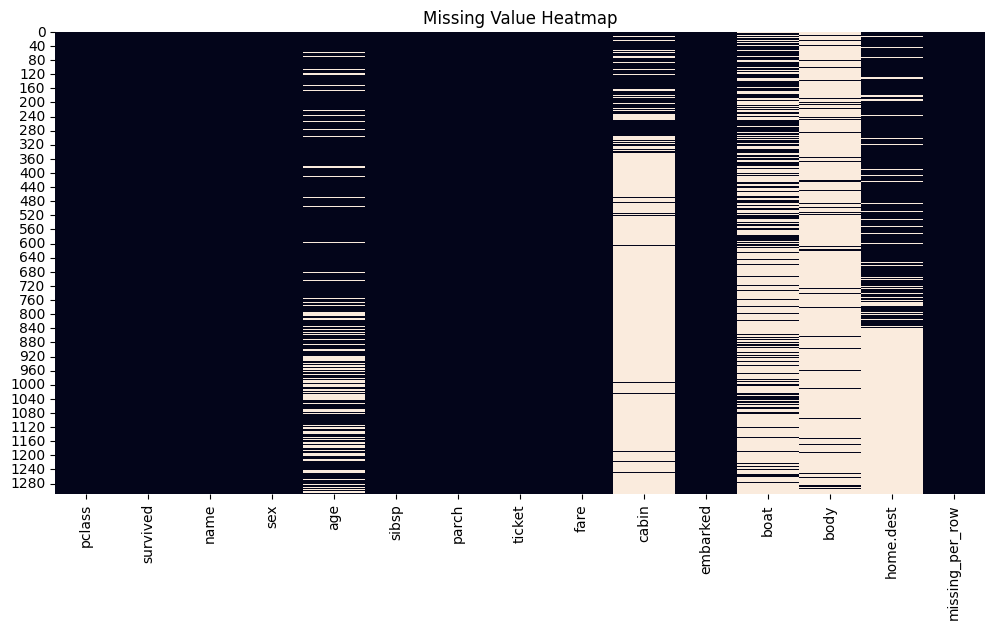

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

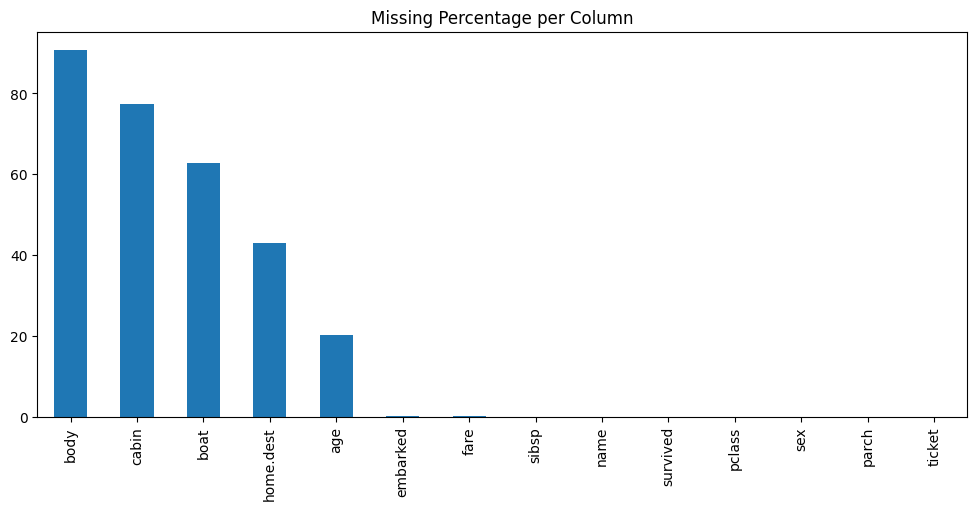

In [ ]:
missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Missing Percentage per Column")
plt.show()

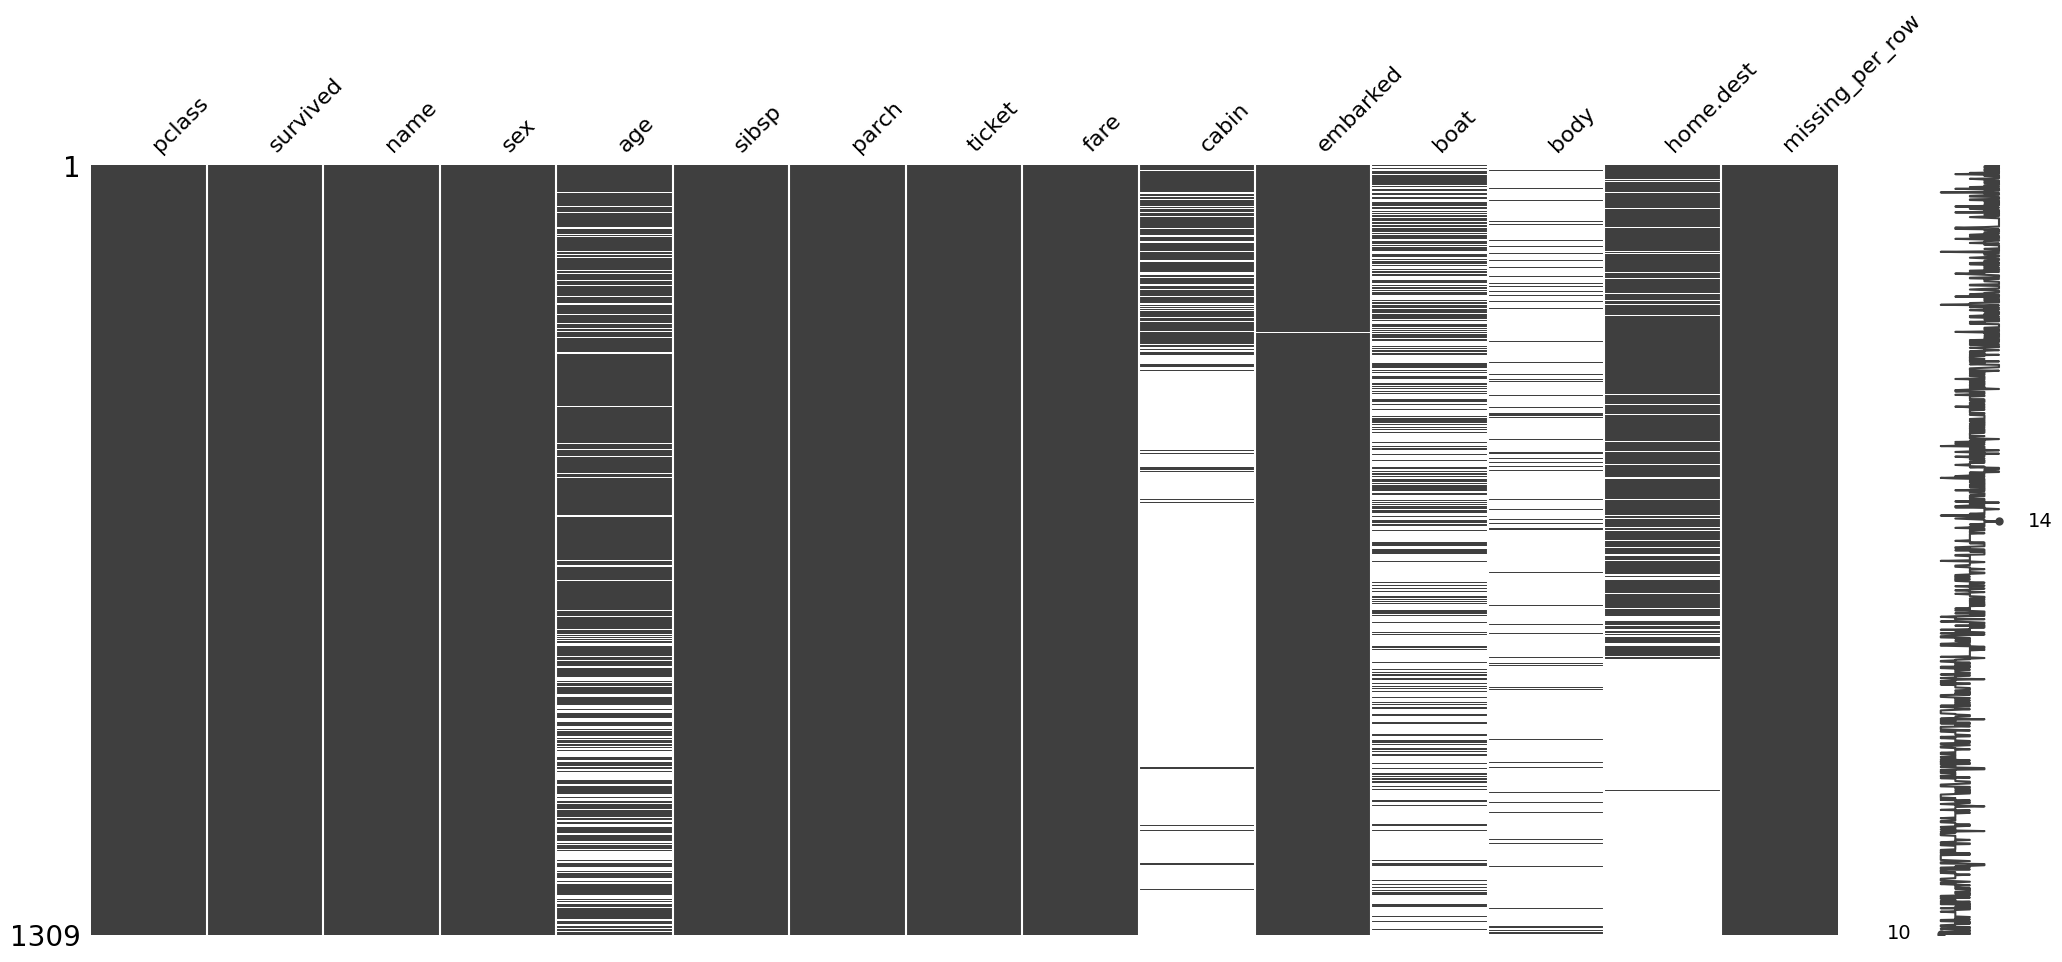

In [ ]:
msno.matrix(df)
plt.show()

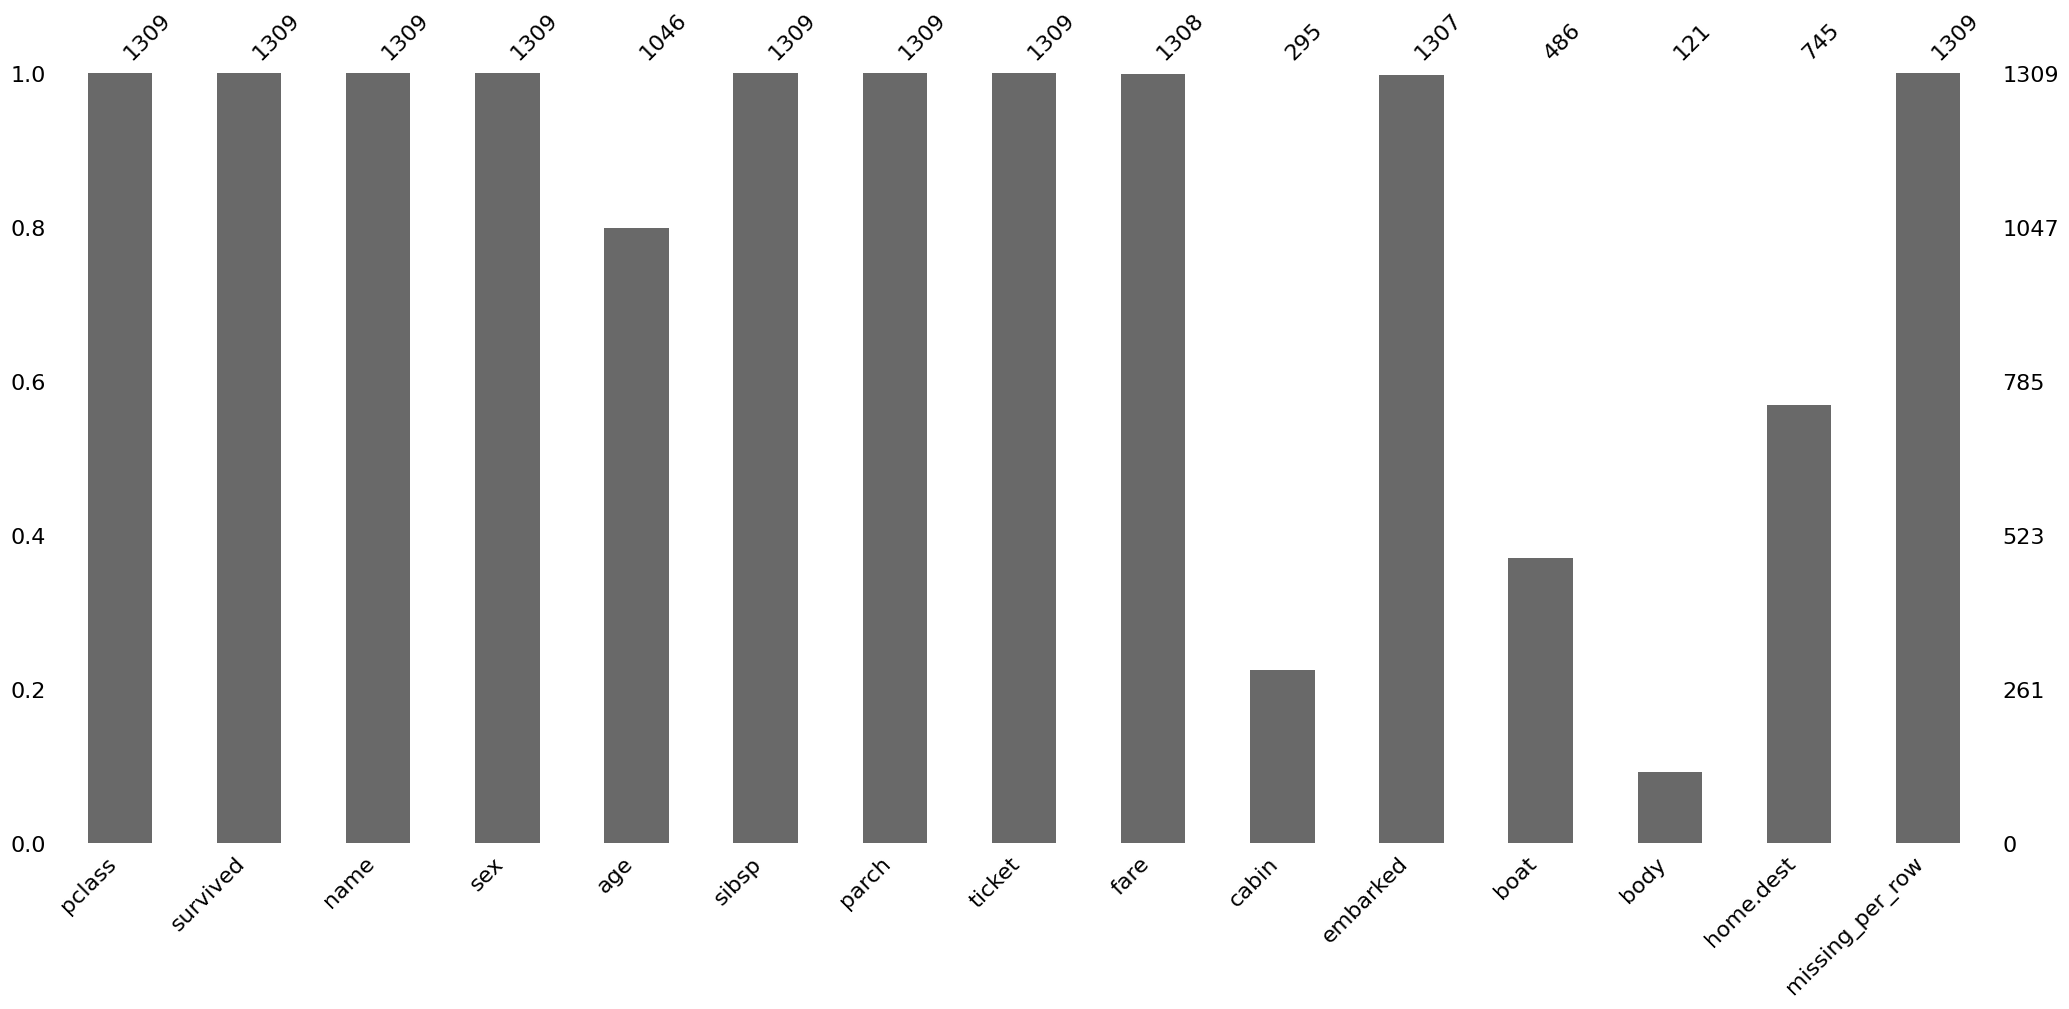

In [ ]:
msno.bar(df)
plt.show()

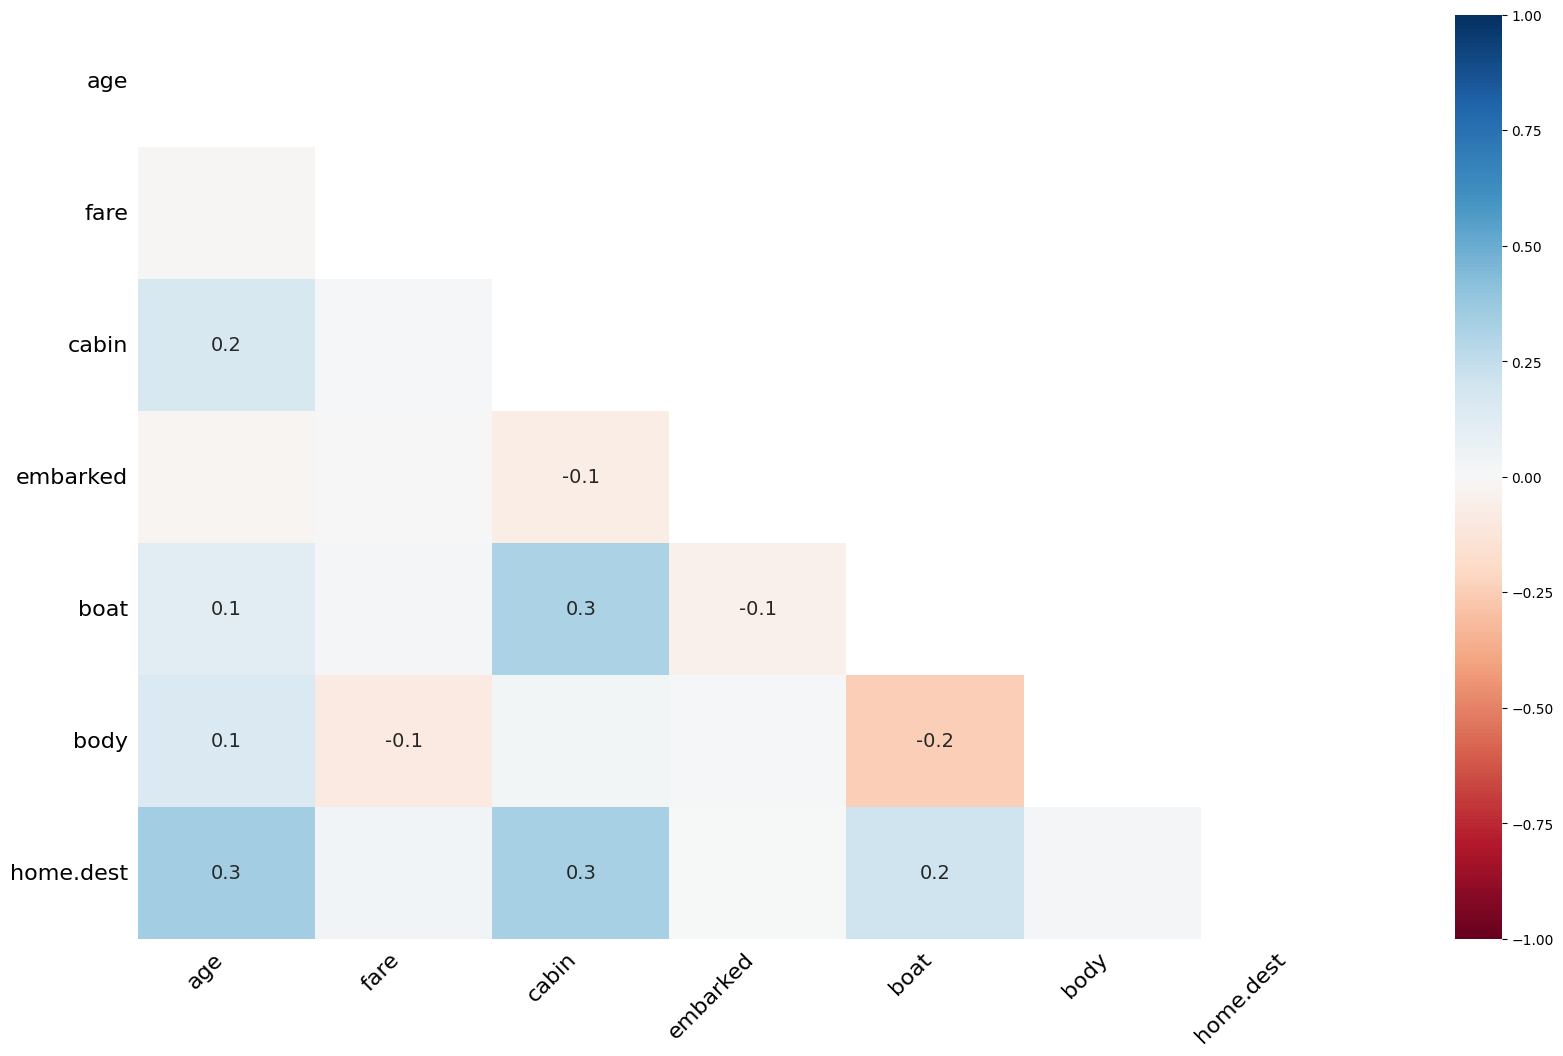

In [ ]:
msno.heatmap(df)
plt.show()

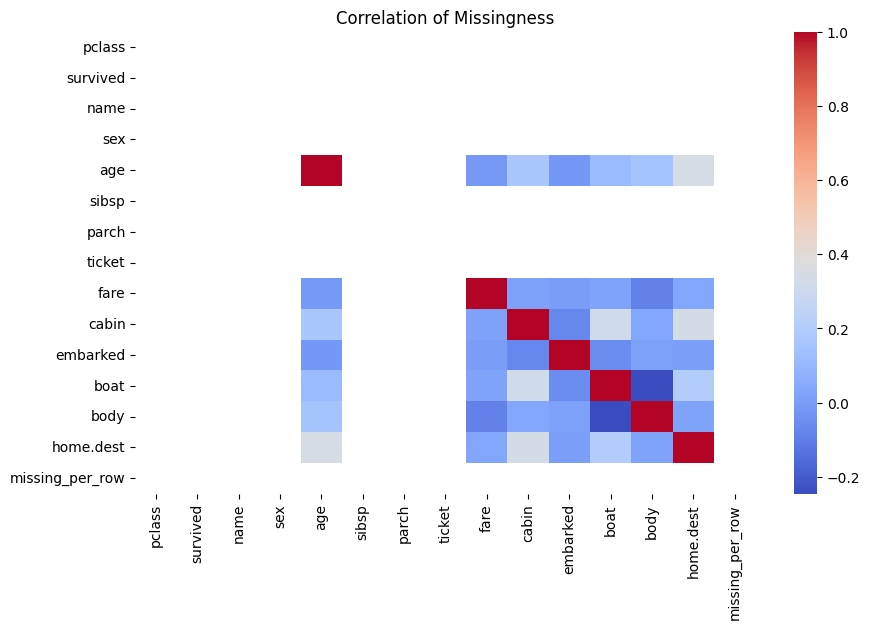

In [ ]:
# 10. Check correlation of missingness
missing_corr = df.isnull().corr()
plt.figure(figsize=(10,6))
sns.heatmap(missing_corr, cmap='coolwarm')
plt.title("Correlation of Missingness")
plt.show()

In [ ]:
# Example: Check relation with target variable
if 'SalePrice' in df.columns:
    print("\nMissing vs Target Analysis:")
    print(df.groupby(df['LotFrontage'].isnull())['SalePrice'].mean())

In [ ]:
# Drop columns with >50% missing
df_drop_cols = df.dropna(thresh=len(df)*0.5, axis=1)

# Drop rows with too many missing values
df_drop_rows = df.dropna(thresh=df.shape[1]*0.5)

In [ ]:
# Separate numeric and categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [ ]:
# Mean Imputation
mean_imputer = SimpleImputer(strategy='mean')
df_mean = df.copy()
df_mean[num_cols] = mean_imputer.fit_transform(df[num_cols])

In [ ]:
# Median Imputation
median_imputer = SimpleImputer(strategy='median')
df_median = df.copy()
df_median[num_cols] = median_imputer.fit_transform(df[num_cols])

In [ ]:
# Mode Imputation
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode = df.copy()
df_mode[cat_cols] = mode_imputer.fit_transform(df[cat_cols])

In [ ]:
# Constant Imputation
const_imputer = SimpleImputer(strategy='constant', fill_value=0)
df_const = df.copy()
df_const[num_cols] = const_imputer.fit_transform(df[num_cols])

In [ ]:
# ================================
# 7. FORWARD / BACKWARD FILL
# ================================
df_ffill = df.fillna(method='ffill')
df_bfill = df.fillna(method='bfill')

/tmp/ipykernel_3293/2941151196.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')
/tmp/ipykernel_3293/2941151196.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method='bfill')


In [ ]:
# ================================
# 8. KNN IMPUTATION
# ================================
knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df.copy()
df_knn[num_cols] = knn_imputer.fit_transform(df[num_cols])

In [ ]:


# ================================
# 9. REGRESSION IMPUTATION (MANUAL)
# ================================

df_reg = df.copy()

for col in num_cols:
    if df_reg[col].isnull().sum() > 0:
        temp_df = df_reg[num_cols].copy()

        # Split into train (non-null) and test (null)
        train = temp_df[temp_df[col].notnull()]
        test = temp_df[temp_df[col].isnull()]

        if len(train) > 0 and len(test) > 0:
            X_train = train.drop(columns=[col])
            y_train = train[col]

            X_test = test.drop(columns=[col])

            # Fill temporary missing values with mean
            X_train = X_train.fillna(X_train.mean())
            X_test = X_test.fillna(X_test.mean())

            model = LinearRegression()
            model.fit(X_train, y_train)

            df_reg.loc[df_reg[col].isnull(), col] = model.predict(X_test)

# ================================
# 10. INTERPOLATION
# ================================
df_interp = df.copy()
df_interp[num_cols] = df_interp[num_cols].interpolate(method='linear')

# ================================
# 11. MICE IMPUTATION (IterativeImputer)
# ================================
mice_imputer = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=0)
df_iter = df.copy()
df_iter[num_cols] = mice_imputer.fit_transform(df[num_cols])

# ================================
# 12. COMPARISON SUMMARY
# ================================
print("\nAfter Imputation (Mean):\n", df_mean.isnull().sum().sum())
print("After Imputation (KNN):\n", df_knn.isnull().sum().sum())
print("After Imputation (MICE):\n", df_iter.isnull().sum().sum())

# ================================
# 13. SAVE CLEANED DATA
# ================================
df_iter.to_csv("cleaned_data.csv", index=False)



After Imputation (Mean):
 2403
After Imputation (KNN):
 2403
After Imputation (MICE):
 2403
